1.Importing the independencies

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2.Data cleaning

In [ ]:
# Loading the data
df = pd.read_csv('chronic_disease_prediction_dataset.csv')

#Removing unnecessary column
df = df.drop('Patient_ID', axis=1)

#changing the target to numeric (Yes=1, No=0)
df['HasChronicDisease'] = df['HasChronicDisease'].map({'Yes': 1, 'No': 0})

#changing text (categorical) columns to dummy variables
df_final = pd.get_dummies(df)

#checking missing values
df_final = df_final.fillna(0)

3.Data visualization

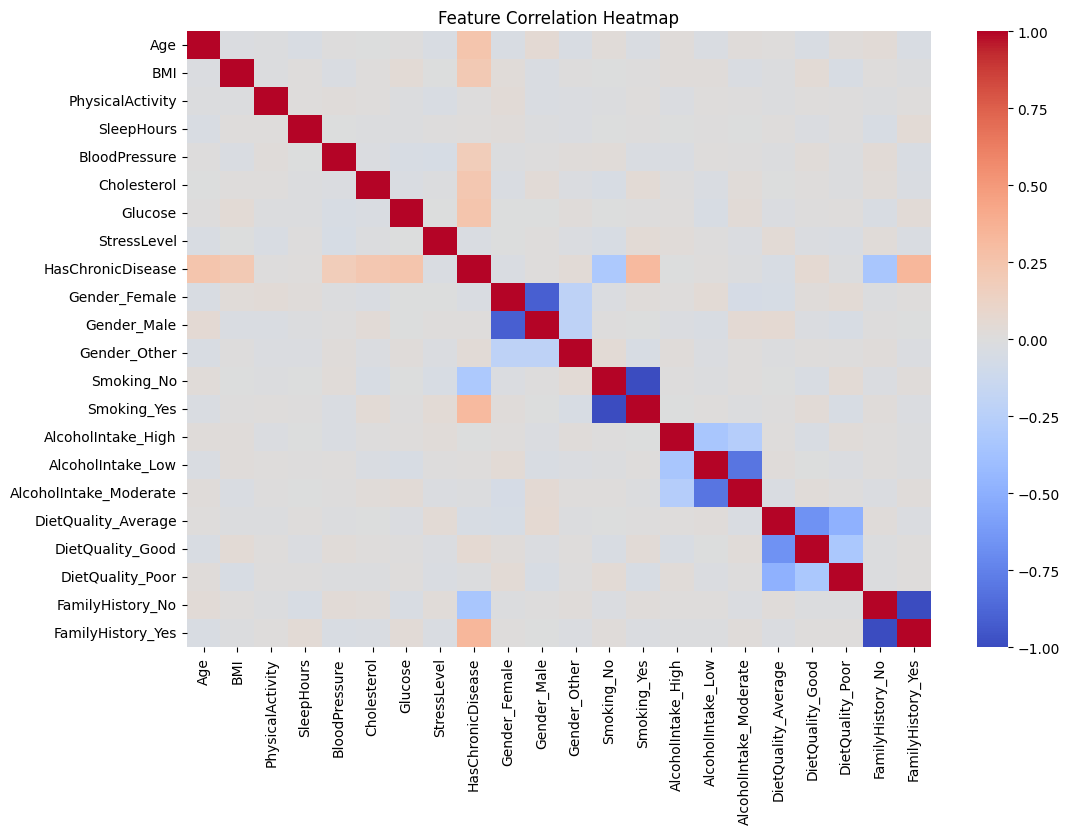

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

4.Splitting the Data into Features and Targets

In [ ]:
# X = Everything except the target
X = df_final.drop('HasChronicDisease', axis=1)

# y = The target we want to predict
y = df_final['HasChronicDisease'].astype(int)

5. Splitting the Data into Test and Training Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {X_train.shape[0]}, Testing rows: {X_test.shape[0]}")

Training rows: 1200, Testing rows: 300


6. Model Training

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model Training Completed!")

Model Training Completed!


7. Model Evaluation

--- Model Performance ---
Accuracy Score: 93.67%

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.95       167
           1       0.97      0.88      0.92       133

    accuracy                           0.94       300
   macro avg       0.94      0.93      0.94       300
weighted avg       0.94      0.94      0.94       300



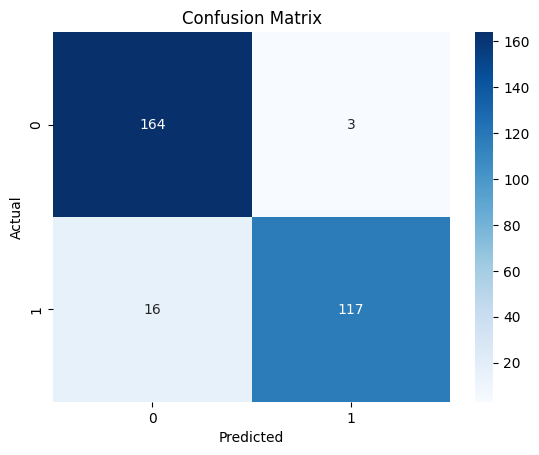

In [ ]:
y_pred = model.predict(X_test)

# Accuracy and Reports
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

8. Save the Model

In [ ]:
import pickle

# 'model' nu neenga train panna variable name-ah inga kudukkanum
# Example: RandomForestClassifier train panni irundha andha variable
filename = 'chronic_disease_model.sav'
pickle.dump(model, open(filename, 'wb'))

print("Chronic Disease Model saved successfully!")

Chronic Disease Model saved successfully!
